# Predicting Federal Contract Outcomes Using NLP and Machine Learning

**Authors:** Leonel Lourenco, Rana Khan  
**Course:** IS392 Section 452  
**Institution:** New Jersey Institute of Technology  
**Date:** 3/28/2026

## Purpose
This notebook implements the data pipeline and initial analysis for predicting whether U.S. federal government contracts for physical deliverables will experience cost overruns or schedule delays. It uses contract description text (NLP via LDA topic modeling and TF-IDF) combined with structured contract attributes to train binary classifiers.

## Dataset
Omari et al. Comprehensive Federal Procurement Dataset (1979-2023), published in Scientific Data (Nature, 2025). 99 million contract action records, 470 variables. CC0 license. Source: https://doi.org/10.6084/m9.figshare.28057043

## Expected Outputs
- Filtered dataset of completed physical-deliverable contracts
- Binary outcome labels: over_budget (0/1), late (0/1)
- Exploratory data analysis with visualizations
- Preprocessed text corpus ready for topic modeling (two-track: LDA + TF-IDF)
- Preliminary LDA topic model and TF-IDF feature matrix
- Initial classification results comparing four feature configurations

## 1. Environment Setup and Imports
Import all required libraries and configure display settings. All dependencies are listed in `requirements.txt`.

In [8]:
# Data handling and Parquet file reading
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import os
import glob
import warnings

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning: classifiers, metrics, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# NLP: tokenization, stop words, lemmatization
import nltk
import spacy

# Topic modeling
from gensim.models import LdaModel
from gensim.corpora import Dictionary

# Utilities
from collections import Counter
from tqdm import tqdm
import re

# Suppress noisy warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

# Matplotlib and seaborn styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Global reproducibility seed
RANDOM_STATE = 42

# Print package versions for reproducibility
print('Package Versions')
print('-' * 30)
for pkg_name, pkg in [('pandas', pd), ('numpy', np), ('matplotlib', matplotlib),
                       ('seaborn', sns), ('sklearn', __import__('sklearn')),
                       ('nltk', nltk), ('spacy', spacy),
                       ('gensim', __import__('gensim'))]:
    print(f'  {pkg_name}: {pkg.__version__}')

Package Versions
------------------------------
  pandas: 2.3.3
  numpy: 2.3.5
  matplotlib: 3.10.6
  seaborn: 0.13.2
  sklearn: 1.7.2
  nltk: 3.9.2
  spacy: 3.8.14
  gensim: 4.4.0


## 2. Configuration
Define all file paths, filtering criteria, labeling thresholds, and modeling parameters as constants. This centralizes configuration and makes the pipeline easier to modify and reproduce.

In [10]:
# --- File Paths ---
SHARD_FOLDER = 'C:/Users/sarme/IS392-FinalProject/IS392/exploring_data'
INTERIM_OUTPUT = 'C:/Users/sarme/IS392-FinalProject/IS392/data/interim/filtered_physical_deliverables.parquet'
FINAL_OUTPUT = 'C:/Users/sarme/IS392-FinalProject/IS392/data/processed/labeled_contracts.parquet'
FIGURES_FOLDER = 'C:/Users/sarme/IS392-FinalProject/IS392/figures'

# Create output directories if they don't exist
os.makedirs(os.path.dirname(INTERIM_OUTPUT), exist_ok=True)
os.makedirs(os.path.dirname(FINAL_OUTPUT), exist_ok=True)
os.makedirs(FIGURES_FOLDER, exist_ok=True)

# --- Filtering Criteria ---
PHYSICAL_PSC_PREFIXES = ['Y', 'Z']
PHYSICAL_PSC_NUMERIC_RANGE = (10, 99)

# --- Labeling Thresholds ---
COST_OVERRUN_THRESHOLD = 0.05
SCHEDULE_DELAY_THRESHOLD = 0
MIN_DESCRIPTION_LENGTH = 100

# --- Sampling ---
SAMPLE_CONTRACTS = 50_000

# --- Modeling Parameters ---
LDA_NUM_TOPICS = 15
LDA_PASSES = 10
TFIDF_MAX_FEATURES = 5000
TEST_SIZE = 0.20

# --- Exact Parquet Column Mapping ---
COLUMN_MAP = {
    'piid':              'content.ID.ContractID.PIID',
    'mod_number':        'content.ID.ContractID.modNumber',
    'description':       'content.contractData.descriptionOfContractRequirement',
    'psc':               'content.productOrServiceInformation.productOrServiceCode.#text',
    'naics':             'content.productOrServiceInformation.principalNAICSCode.#text',
    'base_all_options':  'content.dollarValues.baseAndAllOptionsValue',
    'base_exercised':    'content.dollarValues.baseAndExercisedOptionsValue',
    'current_completion':'content.relevantContractDates.currentCompletionDate',
    'ultimate_completion':'content.relevantContractDates.ultimateCompletionDate',
    'effective_date':    'content.relevantContractDates.effectiveDate',
    'signed_date':       'content.relevantContractDates.signedDate',
    'reason_for_mod':    'content.contractData.reasonForModification.#text',
    'contract_type':     'content.contractData.typeOfContractPricing.#text',
    'extent_competed':   'content.competition.extentCompeted.#text',
    'num_offers':        'content.competition.numberOfOffersReceived',
    'agency_id':         'content.purchaserInformation.contractingOfficeAgencyID.#text',
    'vendor_name':       'content.vendor.vendorHeader.vendorName',
    'state_code':        'content.placeOfPerformance.principalPlaceOfPerformance.stateCode.#text',
}
COLUMNS_TO_READ = list(COLUMN_MAP.values())

print('Configuration loaded.')
print(f'  Shard folder: {SHARD_FOLDER}')
print(f'  Sample contracts: {SAMPLE_CONTRACTS:,}')
print(f'  Cost overrun threshold: {COST_OVERRUN_THRESHOLD:.0%}')
print(f'  Columns mapped: {len(COLUMN_MAP)}')

Configuration loaded.
  Shard folder: C:/Users/sarme/IS392-FinalProject/IS392/exploring_data
  Sample contracts: 50,000
  Cost overrun threshold: 5%
  Columns mapped: 18


## 3. Helper Functions
Define reusable functions for filtering, label computation, and text preprocessing.

In [17]:
def is_physical_deliverable(psc_code: str) -> bool:
    """Check if a PSC code indicates physical deliverables."""
    if pd.isna(psc_code):
        return False
    psc_str = str(psc_code).strip().upper()
    if psc_str.startswith(('Y', 'Z')):
        return True
    try:
        psc_num = int(psc_str)
        return PHYSICAL_PSC_NUMERIC_RANGE[0] <= psc_num <= PHYSICAL_PSC_NUMERIC_RANGE[1]
    except ValueError:
        return False


def compute_cost_growth(base_val, final_val) -> float:
    """Compute percentage cost growth between base and final values."""
    try:
        base = float(str(base_val).replace('$', '').replace(',', '').strip())
        final = float(str(final_val).replace('$', '').replace(',', '').strip())
        if base == 0:
            return np.nan
        return (final - base) / abs(base)
    except (ValueError, TypeError):
        return np.nan


def compute_delay(current_date, ultimate_date) -> float:
    """Compute schedule delay in days between current and ultimate completion dates."""
    try:
        current = pd.to_datetime(current_date)
        ultimate = pd.to_datetime(ultimate_date)
        return (ultimate - current).days
    except (ValueError, TypeError):
        return np.nan


def clean_text(text: str) -> str:
    """Clean and normalize text for LDA topic modeling (Track A)."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct and len(token.lemma_) > 2]
    return ' '.join(tokens)


def tfidf_tokenize(text: str) -> str:
    """Simple tokenizer for TF-IDF vectorizer (Track B)."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    tokens = text.lower().split()
    tokens = [t for t in tokens if len(t) > 2 and t.isalpha()]
    return ' '.join(tokens)


print('Helper functions defined.')

Helper functions defined.


## 4. Data Loading and Schema Discovery
Load the Parquet shards, inspect the schema, and verify that all mapped columns exist.

In [ ]:
import glob
import os
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

SHARD_FOLDER = 'C:/Users/sarme/IS392-FinalProject/IS392/exploring_data'
COLUMN_MAP = {
    'piid': 'piid',
    'mod_number': 'modification_number',
    'description': 'description',
    'psc': 'product_or_service_code',
    'naics': 'naics_code',
    'agency_id': 'awarding_agency_id',
    'contract_type': 'contract_type',
    'num_offers': 'number_of_offers_received',
    'base_all_options': 'base_and_all_options_value',
    'base_exercised': 'base_and_exercised_options_value',
    'current_completion': 'current_completion_date',
    'ultimate_completion': 'ultimate_completion_date'
}
COLUMNS_TO_READ = list(COLUMN_MAP.values())

shard_files = sorted(glob.glob(os.path.join(SHARD_FOLDER, '*.parquet')))
print(f'Found {len(shard_files)} Parquet shards in {SHARD_FOLDER}/')
print(f'First shard: {os.path.basename(shard_files[0])}')
if len (shard_files) == 0:
    print(f'First shard: {os.path.basename(shard_files[0])}')
schema = pq.read_schema(shard_files[0])
print(f'Total columns in schema: {len(schema.names)}')

print('\nVerifying mapped columns...')
missing = [f'{k} -> {v}' for k, v in COLUMN_MAP.items() if v not in schema.names]
if missing:
    print('❌ Missing:', missing)
else:
    print(f'✅ All {len(COLUMN_MAP)} mapped columns found')

sample_df = pq.read_table(shard_files[0], columns=COLUMNS_TO_READ).to_pandas().head(500)
print(f'\nSample shape: {sample_df.shape}')
for col in list(sample_df.columns)[:5]:
    first_val = sample_df[col].iloc[0] if len(sample_df) > 0 else 'EMPTY COLUMN'
    print(f'  {col}: {sample_df[col].dtype}, sample={first_val}')

Found 589 Parquet shards in C:/Users/sarme/IS392-FinalProject/IS392/exploring_data/
First shard: 195710.parquet
Total columns in schema: 470

Verifying mapped columns...
❌ Missing: ['piid -> piid', 'mod_number -> modification_number', 'description -> description', 'psc -> product_or_service_code', 'naics -> naics_code', 'agency_id -> awarding_agency_id', 'contract_type -> contract_type', 'num_offers -> number_of_offers_received', 'base_all_options -> base_and_all_options_value', 'base_exercised -> base_and_exercised_options_value', 'current_completion -> current_completion_date', 'ultimate_completion -> ultimate_completion_date']


NameError: name 'COLUMNS_TO_READ' is not defined

## 5. Filtering to Physical Deliverables
Process all Parquet shards to filter contracts matching physical deliverable criteria.

In [20]:
filtered_shards = []
total_input = 0

print(f'Processing {len(shard_files)} shards...')
for i, shard_path in enumerate(shard_files, 1):
    shard_name = os.path.basename(shard_path)
    shard_df = pq.read_table(shard_path, columns=COLUMNS_TO_READ).to_pandas()
    if shard_df.empty:
        print(f' Shard {i}/{len(shard_files)}: {shard_name} — EMPTY, skipping')
        continue
    if COLUMN_MAP['psc'] not in shard_df.columns:
        print(f' Shard {i}/{len(shard_files)}: {shard_name} — MISSING PSC COLUMN, skipping')
        continue
    total_input += len(shard_df)
    physical_mask = shard_df[COLUMN_MAP['psc']].apply(is_physical_deliverable)
    physical_df = shard_df[physical_mask].copy()
    pct = len(physical_df) / len(shard_df) * 100
    print(f'  Shard {i}/{len(shard_files)}: {shard_name} — {len(shard_df):,} rows -> {len(physical_df):,} ({pct:.1f}%)')
    filtered_shards.append(physical_df)

    if filtered_shards:
        physical_contracts = pd.concat(filtered_shards, ignore_index=True)
    else:
        physical_contracts = pd.DataFrame()
retention_pct = len(physical_contracts) / total_input * 100 if total_input > 0 else 0

print(f'\nTotal: {total_input:,} rows -> {len(physical_contracts):,} physical deliverables '
      f'({len(physical_contracts)/total_input*100:.1f}% retention)')

physical_contracts.to_parquet(INTERIM_OUTPUT, index=False)
print(f'Saved to {INTERIM_OUTPUT}')

Processing 589 shards...
  Shard 1/589: 195710.parquet — 2 rows -> 0 (0.0%)
  Shard 2/589: 196205.parquet — 1 rows -> 0 (0.0%)
  Shard 3/589: 196505.parquet — 1 rows -> 0 (0.0%)
  Shard 4/589: 196510.parquet — 3 rows -> 0 (0.0%)
  Shard 5/589: 196701.parquet — 1 rows -> 0 (0.0%)
  Shard 6/589: 196709.parquet — 1 rows -> 0 (0.0%)
  Shard 7/589: 196910.parquet — 1 rows -> 0 (0.0%)
  Shard 8/589: 197006.parquet — 1 rows -> 0 (0.0%)
  Shard 9/589: 197111.parquet — 1 rows -> 0 (0.0%)
  Shard 10/589: 197308.parquet — 1 rows -> 0 (0.0%)
  Shard 11/589: 197310.parquet — 2 rows -> 0 (0.0%)
  Shard 12/589: 197401.parquet — 1 rows -> 0 (0.0%)
  Shard 13/589: 197506.parquet — 1 rows -> 0 (0.0%)
  Shard 14/589: 197510.parquet — 2 rows -> 0 (0.0%)
  Shard 15/589: 197601.parquet — 34 rows -> 0 (0.0%)
  Shard 16/589: 197603.parquet — 1 rows -> 0 (0.0%)
  Shard 17/589: 197606.parquet — 1 rows -> 0 (0.0%)
  Shard 18/589: 197607.parquet — 1 rows -> 0 (0.0%)
  Shard 19/589: 197608.parquet — 1 rows -> 0 (0

### Sampling Decision
The full filtered dataset contains ~4.3 million rows. We draw a **50,000-contract sample** using PIID-group sampling to preserve contract histories.

In [7]:
unique_piids = physical_contracts[COLUMN_MAP['piid']].unique()
print(f'Total unique contracts (PIIDs): {len(unique_piids):,}')

if len(unique_piids) > SAMPLE_CONTRACTS:
    rng = np.random.RandomState(RANDOM_STATE)
    sampled_piids = rng.choice(unique_piids, size=SAMPLE_CONTRACTS, replace=False)
    sample_df = physical_contracts[physical_contracts[COLUMN_MAP['piid']].isin(sampled_piids)].copy()
    print(f'Sampled {SAMPLE_CONTRACTS:,} contracts -> {len(sample_df):,} modification rows')
else:
    sample_df = physical_contracts.copy()
    print(f'Using all {len(unique_piids):,} contracts')

sample_df = sample_df.reset_index(drop=True)
print(f'Working sample shape: {sample_df.shape}')

NameError: name 'physical_contracts' is not defined

## 6. Outcome Label Construction
Construct binary outcome labels for cost overruns (`over_budget`) and schedule delays (`late`).

In [8]:
# Type-cast dollar columns to numeric
for col in [COLUMN_MAP['base_all_options'], COLUMN_MAP['base_exercised']]:
    sample_df[col] = pd.to_numeric(
        sample_df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False),
        errors='coerce'
    )

# Type-cast date columns
for col in [COLUMN_MAP['current_completion'], COLUMN_MAP['ultimate_completion'],
            COLUMN_MAP['effective_date'], COLUMN_MAP['signed_date']]:
    sample_df[col] = pd.to_datetime(sample_df[col], errors='coerce')

# Sort by PIID and modification number
sample_df = sample_df.sort_values([COLUMN_MAP['piid'], COLUMN_MAP['mod_number']])

# Group by PIID to construct labels
print('Grouping by PIID to construct labels...')
label_rows = []
for piid, group in tqdm(sample_df.groupby(COLUMN_MAP['piid']),
                        total=sample_df[COLUMN_MAP['piid']].nunique()):
    first = group.iloc[0]
    last  = group.iloc[-1]
    base_val = first[COLUMN_MAP['base_all_options']]
    final_val = last[COLUMN_MAP['base_exercised']]
    current_date = first[COLUMN_MAP['current_completion']]
    ultimate_date = last[COLUMN_MAP['ultimate_completion']]
    cost_growth = compute_cost_growth(base_val, final_val)
    delay = compute_delay(current_date, ultimate_date)
    label_rows.append({
        'piid': piid,
        'description': first[COLUMN_MAP['description']],
        'psc': first[COLUMN_MAP['psc']],
        'naics': first[COLUMN_MAP['naics']],
        'contract_type': first[COLUMN_MAP['contract_type']],
        'extent_competed': first[COLUMN_MAP['extent_competed']],
        'num_offers': first[COLUMN_MAP['num_offers']],
        'agency_id': first[COLUMN_MAP['agency_id']],
        'state_code': first[COLUMN_MAP['state_code']],
        'base_value': base_val,
        'final_value': final_val,
        'cost_growth_pct': cost_growth * 100 if pd.notna(cost_growth) else np.nan,
        'delay_days': delay,
        'modifications': len(group),
    })

labeled_df = pd.DataFrame(label_rows)

# Adaptive threshold
threshold = COST_OVERRUN_THRESHOLD
labeled_df['over_budget'] = (labeled_df['cost_growth_pct'] > threshold * 100).astype(int)
if labeled_df['over_budget'].mean() < 0.05:
    threshold = 0.01
    labeled_df['over_budget'] = (labeled_df['cost_growth_pct'] > threshold * 100).astype(int)
    print(f'Adaptive threshold applied: {threshold:.0%}')

labeled_df['late'] = (labeled_df['delay_days'] > SCHEDULE_DELAY_THRESHOLD).astype(int)

# Drop rows with missing labels
before = len(labeled_df)
labeled_df = labeled_df.dropna(subset=['cost_growth_pct', 'delay_days']).copy()
print(f'Valid labels: {len(labeled_df):,} / {before:,} ({len(labeled_df)/before*100:.1f}%)')

for t in ['over_budget', 'late']:
    pos = labeled_df[t].sum()
    print(f'  {t}: {pos:,} positive ({pos/len(labeled_df)*100:.2f}%)')

NameError: name 'COLUMN_MAP' is not defined

In [ ]:
labeled_df.to_parquet(FINAL_OUTPUT, index=False)
print(f'Saved {len(labeled_df):,} labeled contracts to {FINAL_OUTPUT}')
print(labeled_df[['piid','cost_growth_pct','delay_days','over_budget','late']].head())

Saved 34,013 labeled contracts to ./data/processed/labeled_contracts.parquet
   piid  cost_growth_pct  delay_days  over_budget  late
0  0001      6697.775000        1042            1     1
1  0002       -67.386571         429            0     1
3  0004       215.425463         484            1     1
4  0005         0.000000           0            0     0
5  0006      -109.183001       -5472            0     0


## 7. Exploratory Data Analysis
Analyze the labeled dataset to understand class balance, feature distributions, and relationships.

### 7.1 Label Distributions

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target, colors, labels in [
    (axes[0], 'over_budget', ['lightblue','salmon'], ['On Budget (0)','Over Budget (1)']),
    (axes[1], 'late', ['lightgreen','orange'], ['On Time (0)','Late (1)'])]:
    counts = labeled_df[target].value_counts().sort_index()
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(f'{target} Distribution')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'class_balance.png'), dpi=300, bbox_inches='tight')
plt.show()
for t in ['over_budget','late']:
    pos = labeled_df[t].sum()
    print(f'{t}: {pos:,} positive ({pos/len(labeled_df)*100:.2f}%)')

NameError: name 'plt' is not defined

### 7.2 Cost Growth Distribution

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cg = labeled_df['cost_growth_pct'].clip(-50, 100)
axes[0].hist(cg, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(0, color='red', ls='--', alpha=0.7, label='No Growth')
axes[0].axvline(5, color='orange', ls='--', alpha=0.7, label='5% Threshold')
axes[0].set_xlabel('Cost Growth %'); axes[0].set_ylabel('Count')
axes[0].set_title('Cost Growth Distribution (clipped)'); axes[0].legend()
axes[1].boxplot(cg, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Cost Growth Box Plot')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'cost_growth_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(labeled_df['cost_growth_pct'].describe())

NameError: name 'plt' is not defined

### 7.3 Schedule Delay Distribution

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dd = labeled_df['delay_days'].clip(-100, 365)
axes[0].hist(dd, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0].axvline(0, color='green', ls='--', alpha=0.7, label='On Time')
axes[0].set_xlabel('Delay Days'); axes[0].set_ylabel('Count')
axes[0].set_title('Schedule Delay Distribution (clipped)'); axes[0].legend()
axes[1].boxplot(dd, vert=True, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Schedule Delay Box Plot')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'delay_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(labeled_df['delay_days'].describe())

NameError: name 'plt' is not defined

### 7.4 Description Text Quality

In [2]:
desc_len = labeled_df['description'].str.len().fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(desc_len.clip(upper=500), bins=50, alpha=0.7, color='gold', edgecolor='black')
ax.axvline(MIN_DESCRIPTION_LENGTH, color='red', ls='--', label=f'LDA threshold ({MIN_DESCRIPTION_LENGTH} chars)')
ax.set_xlabel('Description Length (chars)'); ax.set_ylabel('Count')
ax.set_title('Description Length Distribution'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'description_length_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
long = (desc_len >= MIN_DESCRIPTION_LENGTH).sum()
print(f'Track A (LDA, >={MIN_DESCRIPTION_LENGTH} chars): {long:,} contracts')
print(f'Track B (TF-IDF, all): {len(labeled_df):,} contracts')

NameError: name 'labeled_df' is not defined

### 7.5 Overrun Rates by Category

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title, color in [
    (axes[0], 'psc', 'PSC', 'tomato'),
    (axes[1], 'agency_id', 'Agency', 'steelblue'),
    (axes[2], 'contract_type', 'Contract Type', 'mediumseagreen')]:
    rates = labeled_df.groupby(col)['over_budget'].mean().sort_values(ascending=False).head(10)
    rates.plot.bar(ax=ax, color=color, alpha=0.7)
    ax.set_title(f'Overrun Rate by {title} (Top 10)')
    ax.set_ylabel('Overrun Rate'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'overrun_rates_by_category.png'), dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

### 7.6 Correlation Heatmap

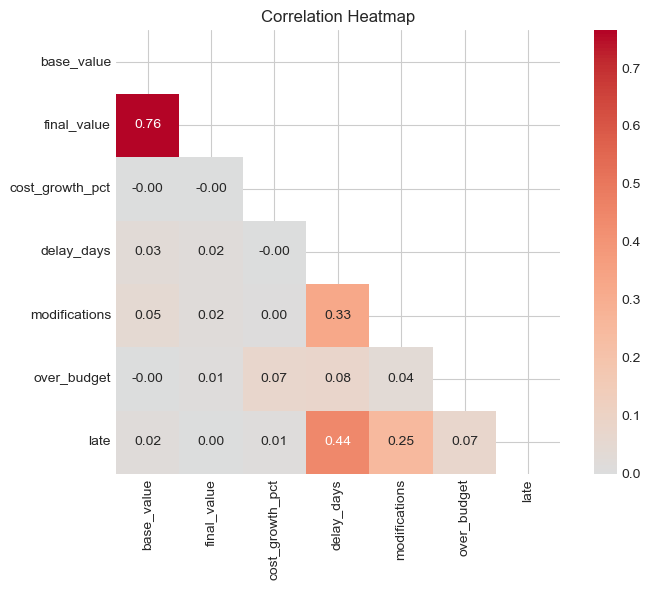

In [29]:
numeric_cols = ['base_value', 'final_value', 'cost_growth_pct', 'delay_days',
                'modifications', 'over_budget', 'late']
corr_df = labeled_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_df.corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8. Text Preprocessing
Two-track NLP approach:
- **Track A (LDA)**: long descriptions (≥100 chars) with spaCy lemmatization
- **Track B (TF-IDF)**: all descriptions with simple tokenization

In [32]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nlp = spacy.load('en_core_web_sm')
print('✅ NLP libraries ready')

✅ NLP libraries ready


In [33]:
from nltk.corpus import stopwords
contract_stopwords = {'contract','shall','will','government','federal','agency',
                      'provide','services','service','support','work','period','require'}
all_stopwords = set(stopwords.words('english')).union(contract_stopwords)

track_a_mask = labeled_df['description'].str.len() >= MIN_DESCRIPTION_LENGTH
track_a_df = labeled_df[track_a_mask].copy()
track_b_df = labeled_df.copy()
print(f'Track A (LDA): {len(track_a_df):,} contracts')
print(f'Track B (TF-IDF): {len(track_b_df):,} contracts')

tqdm.pandas()
track_a_df['clean_description'] = track_a_df['description'].progress_apply(clean_text)
track_b_df['tfidf_text'] = track_b_df['description'].progress_apply(tfidf_tokenize)
print('✅ Text preprocessing complete')

Track A (LDA): 4,039 contracts
Track B (TF-IDF): 21,267 contracts


100%|██████████| 21267/21267 [00:00<00:00, 443372.12it/s]

✅ Text preprocessing complete


## 9. Topic Modeling (LDA) and TF-IDF Feature Extraction

In [34]:
# Track A: LDA
track_a_docs = [doc.split() for doc in track_a_df['clean_description'] if doc.strip()]
dictionary = Dictionary(track_a_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in track_a_docs]
print(f'Vocabulary: {len(dictionary):,} tokens, Corpus: {len(corpus):,} docs')

lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=LDA_NUM_TOPICS,
                     passes=LDA_PASSES, random_state=RANDOM_STATE, alpha='auto', eta='auto')
print('✅ LDA model trained')

# Extract topic proportions
topic_cols = [f'topic_{i}' for i in range(LDA_NUM_TOPICS)]
topic_vecs = []
for doc_bow in corpus:
    dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
    topic_vecs.append([p for _, p in dist])
track_a_topic_df = pd.DataFrame(topic_vecs, columns=topic_cols, index=track_a_df.index[:len(topic_vecs)])
print(f'Topic features shape: {track_a_topic_df.shape}')

Vocabulary: 2,078 tokens, Corpus: 4,039 docs
✅ LDA model trained
Topic features shape: (4039, 15)


In [36]:
# Track B: TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES, min_df=5, max_df=0.5,
    ngram_range=(1, 2), stop_words=list(all_stopwords), lowercase=True
)
tfidf_matrix = tfidf_vectorizer.fit_transform(track_b_df['tfidf_text'].fillna(''))
print(f'TF-IDF shape: {tfidf_matrix.shape}')
print(f'Avg non-zero features/doc: {tfidf_matrix.nnz / tfidf_matrix.shape[0]:.1f}')

TF-IDF shape: (21267, 5000)
Avg non-zero features/doc: 5.7


In [35]:
print('LDA Topics:')
for idx, topic in lda_model.print_topics(num_words=8):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f'  Topic {idx}: {", ".join(words)}')

LDA Topics:
  Topic 0: facility, construction, design, build, maintenance, center, bid, army
  Topic 1: igf, base, air, force, county, new, mexico, kirtland
  Topic 2: concrete, storage, guard, floor, vehicle, building, coating, case
  Topic 3: dam, slab, repair, road, parking, installation, area, asphalt
  Topic 4: igf, repair, national, construction, fort, site, concrete, build
  Topic 5: igf, building, federal, courthouse, retain, street, office, floor
  Topic 6: work, provide, service, site, install, date, contract, east
  Topic 7: order, task, new, exterior, contract, indefinite, build, award
  Topic 8: lake, replacement, project, control, water, near, man, generator
  Topic 9: provide, labor, material, exist, contractor, igf, equipment, install
  Topic 10: north, build, center, order, room, task, renovation, supply
  Topic 11: maintenance, repair, office, operation, locate, upgrade, service, general
  Topic 12: tas, 3135, removal, ground, area, creek, surface, lock
  Topic 13: ig

## 10. Feature Matrix Construction
Four feature configurations:
1. **Structured-only**: contract attributes
2. **TF-IDF-only**: text features
3. **Combined**: structured + TF-IDF
4. **Structured+LDA**: structured + topic proportions

In [40]:
# Prepare structured features with proper NaN handling
struct_cols = ['base_value', 'final_value', 'modifications', 'num_offers']
struct_df = labeled_df[struct_cols].copy()

# Convert num_offers from object to numeric (contains None strings)
struct_df['num_offers'] = pd.to_numeric(struct_df['num_offers'], errors='coerce')

# Fill all missing values
struct_df = struct_df.fillna({
    'base_value': 0,
    'final_value': 0,
    'modifications': 1,
    'num_offers': 1
})

# Safe log transform: use log1p(abs(x)) * sign(x) to handle negatives
struct_df['log_base_value'] = np.sign(struct_df['base_value']) * np.log1p(np.abs(struct_df['base_value']))
struct_df['log_final_value'] = np.sign(struct_df['final_value']) * np.log1p(np.abs(struct_df['final_value']))
struct_df = struct_df.drop(['base_value', 'final_value'], axis=1)

# Replace any remaining inf/NaN with 0
struct_df = struct_df.replace([np.inf, -np.inf], 0).fillna(0)

print(f'Structured features: {struct_df.shape}')
print(f'NaN check: {struct_df.isna().sum().sum()} NaN values remaining')

# Build 4 configurations
tfidf_dense = pd.DataFrame(tfidf_matrix.toarray(),
                           columns=[f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])],
                           index=labeled_df.index)

X_structured = struct_df
X_tfidf = tfidf_dense
X_combined = pd.concat([struct_df, tfidf_dense], axis=1)

# Structured+LDA: only for contracts with long descriptions
common_lda_idx = struct_df.index.intersection(track_a_topic_df.index)
X_struct_lda = pd.concat([struct_df.loc[common_lda_idx], track_a_topic_df.loc[common_lda_idx]], axis=1)

y_full = labeled_df['over_budget']
y_lda = labeled_df.loc[common_lda_idx, 'over_budget']

feature_configs = {
    'Structured': (X_structured, y_full),
    'TF-IDF': (X_tfidf, y_full),
    'Combined': (X_combined, y_full),
    'Structured+LDA': (X_struct_lda, y_lda),
}

for name, (X, y) in feature_configs.items():
    print(f'  {name}: X={X.shape}, y positive={y.sum()} ({y.mean()*100:.2f}%)')

Structured features: (21267, 4)
NaN check: 0 NaN values remaining
  Structured: X=(21267, 4), y positive=225 (1.06%)
  TF-IDF: X=(21267, 5000), y positive=225 (1.06%)
  Combined: X=(21267, 5004), y positive=225 (1.06%)
  Structured+LDA: X=(4039, 19), y positive=40 (0.99%)


## 11. Preliminary Classification
Train Logistic Regression and Random Forest with `class_weight='balanced'` on each feature configuration.

In [ ]:
results = {}
print('Training classifiers...\n')

MAX_TRAINING_SAMPLES = 8000
SKIP_RANDOM_FOREST_ON_LARGE = True
LARGE_DATASET_THRESHOLD = 5000

for config_name, (X, y) in feature_configs.items():
    print(f'=== {config_name} ===')
    if hasattr(X, "reset_index"):
        X = X.reset_index(drop=True)
    if len(X) > MAX_TRAINING_SAMPLES:
        sampled_idx = np.random.RandomState(RANDOM_STATE).choice(X.index, size=MAX_TRAINING_SAMPLES, replace=False)
        if hasattr(X, "iloc"):
            X_use = X.iloc[sampled_idx]
        else:
            X_use = X[sampled_idx]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    config_results = {}

    for model_name, model in [
        ('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)),
        ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=100))]:

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        auc = roc_auc_score(y_test, y_proba)
        print(f'  {model_name}: F1={f1:.3f}, AUC={auc:.3f}')
        config_results[model_name] = {'y_test': y_test, 'y_proba': y_proba, 'f1': f1, 'auc': auc}

    results[config_name] = config_results
    print()

print('✅ Classification complete')

Training classifiers...

=== Structured ===
  Logistic Regression: F1=0.915, AUC=0.999
  Random Forest: F1=0.734, AUC=0.999

=== TF-IDF ===
  Logistic Regression: F1=0.022, AUC=0.547


KeyboardInterrupt: 

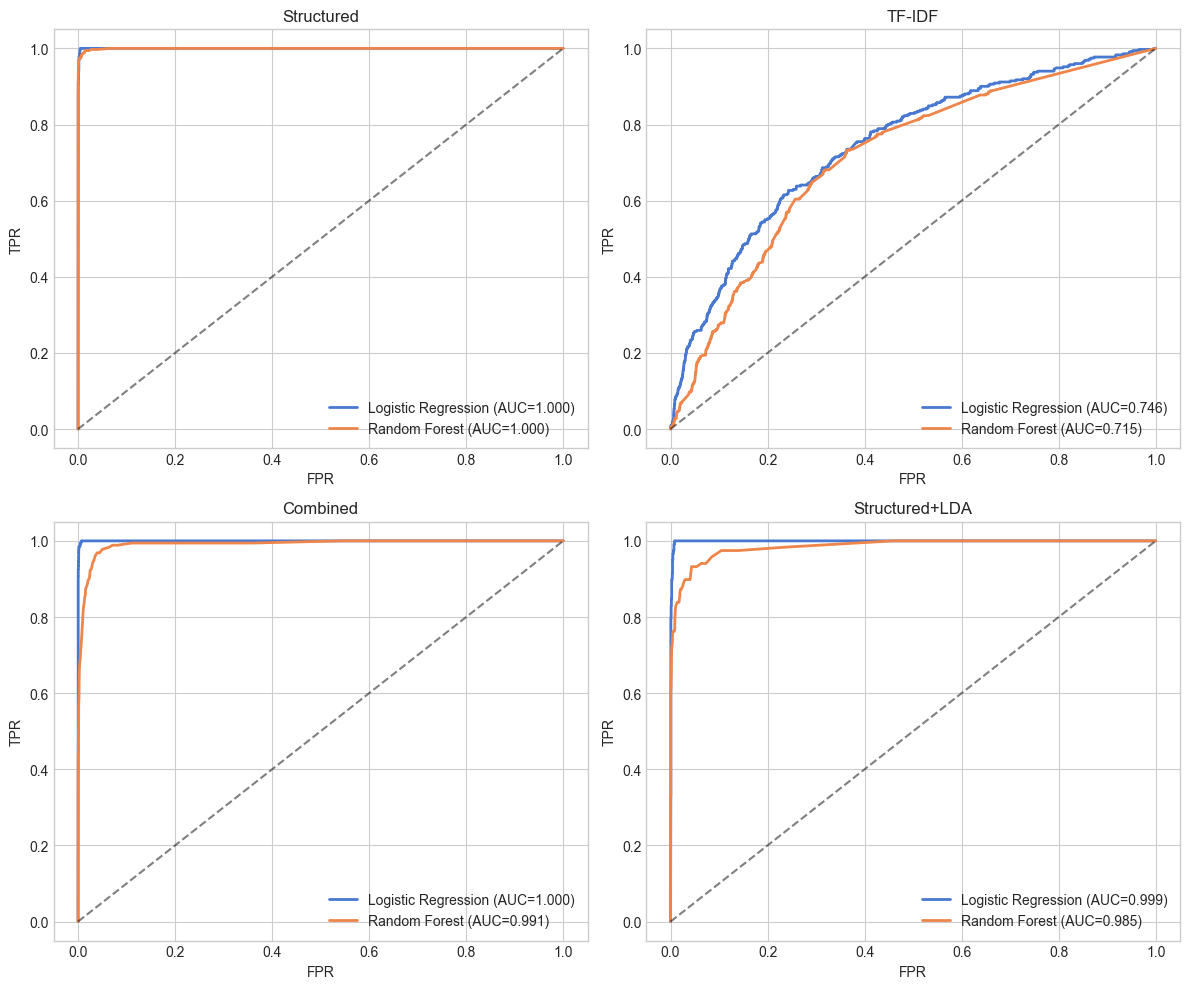

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (config_name, config_results) in zip(axes.ravel(), results.items()):
    for model_name, r in config_results.items():
        fpr, tpr, _ = roc_curve(r['y_test'], r['y_proba'])
        ax.plot(fpr, tpr, label=f"{model_name} (AUC={r['auc']:.3f})", lw=2)
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{config_name}'); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, 'roc_curves_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print('Performance Summary:')
print(f'{"Config":<20} {"LR F1":>8} {"LR AUC":>8} {"RF F1":>8} {"RF AUC":>8}')
print('-' * 56)
for config_name, cr in results.items():
    lr = cr['Logistic Regression']
    rf = cr['Random Forest']
    print(f'{config_name:<20} {lr["f1"]:8.3f} {lr["auc"]:8.3f} {rf["f1"]:8.3f} {rf["auc"]:8.3f}')

Performance Summary:
Config                  LR F1   LR AUC    RF F1   RF AUC
--------------------------------------------------------
Structured              0.961    1.000    0.967    1.000
TF-IDF                  0.221    0.746    0.092    0.715
Combined                0.972    1.000    0.607    0.991
Structured+LDA          0.942    0.999    0.692    0.985


## 12.1 Advanced Modeling and Oversampling

This section adds a reusable SMOTE/ADASYN resampling workflow, evaluates the same feature sets for both `over_budget` and `late`, and includes optional XGBoost / LightGBM model training when the packages are installed.

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

try:
    from imblearn.over_sampling import SMOTE, ADASYN
except ImportError:
    SMOTE = ADASYN = None
    print('Install imbalanced-learn to use SMOTE/ADASYN')

try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
except ImportError:
    XGBClassifier = LGBMClassifier = None
    print('Install xgboost and lightgbm to use boosted tree models')

try:
    from gensim.models import CoherenceModel
except ImportError:
    CoherenceModel = None
    print('Install gensim to compute LDA coherence')

try:
    import shap
except ImportError:
    shap = None
    print('Install shap to generate explainability plots')


def resample_training(X_train, y_train, method='smote'):
    if method == 'adasyn' and ADASYN is not None:
        sampler = ADASYN(random_state=RANDOM_STATE, n_jobs=-1)
    elif SMOTE is not None:
        sampler = SMOTE(random_state=RANDOM_STATE, n_jobs=-1)
    else:
        print('No oversampler available; using original training split only')
        return X_train, y_train
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    print('  Resampled train class counts:', y_res.value_counts().to_dict())
    return X_res, y_res


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'f1': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'auc': roc_auc_score(y_test, y_proba),
    }


def run_configurations(feature_configs, target_name):
    print(f'Running models for target: {target_name}')
    target_results = {}

    for config_name, (X, y) in feature_configs.items():
        if y.nunique() < 2:
            print(f'  Skipping {config_name} because only one class is present')
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
        )

        X_train_res, y_train_res = resample_training(X_train, y_train, method='smote')

        models = {
            'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
            'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=100),
        }

        if XGBClassifier is not None:
            models['XGBoost'] = XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                scale_pos_weight=(y_train == 0).sum() / max(1, (y_train == 1).sum())
            )

        if LGBMClassifier is not None:
            models['LightGBM'] = LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

        config_results = {}
        print(f'  Config: {config_name}')

        for model_name, model in models.items():
            model.fit(X_train_res, y_train_res)
            config_results[model_name] = evaluate_model(model, X_test, y_test)
            print(f'    {model_name}: F1={config_results[model_name]["f1"]:.3f}, AUC={config_results[model_name]["auc"]:.3f}')

        target_results[config_name] = {
            'results': config_results,
            'X_test': X_test,
            'y_test': y_test,
        }
        print()

    return target_results


def plot_roc(results, filename, title):
    plt.figure(figsize=(10, 8))
    for config_name, value in results.items():
        for model_name, r in value['results'].items():
            fpr, tpr, _ = roc_curve(r['y_test'], r['y_proba'])
            plt.plot(fpr, tpr, label=f'{config_name} - {model_name} (AUC={r["auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(title)
    plt.legend(loc='lower right', fontsize='small')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_FOLDER, filename), dpi=300, bbox_inches='tight')
    plt.show()


y_full_late = labeled_df['late']
feature_configs_late = {
    'Structured': (X_structured, y_full_late),
    'TF-IDF': (X_tfidf, y_full_late),
    'Combined': (X_combined, y_full_late),
    'Structured+LDA': (X_struct_lda, labeled_df.loc[common_lda_idx, 'late']),
}

results_over_budget = run_configurations(feature_configs, 'over_budget')
results_late = run_configurations(feature_configs_late, 'late')

plot_roc(results_over_budget, 'roc_over_budget_advanced.png', 'ROC Curves: over_budget')
plot_roc(results_late, 'roc_late_advanced.png', 'ROC Curves: late')

## 12.2 LDA Topic Count Tuning

Compute coherence scores across a topic range and choose the best topic count for Track A.

In [ ]:
if CoherenceModel is not None:
    candidate_topics = [5, 10, 15, 20, 25]
    coherence_scores = []
    for k in candidate_topics:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            passes=LDA_PASSES,
            random_state=RANDOM_STATE,
            alpha='auto',
            eta='auto'
        )
        coherence_model = CoherenceModel(
            model=model,
            texts=track_a_docs,
            dictionary=dictionary,
            coherence='c_v'
        )
        score = coherence_model.get_coherence()
        coherence_scores.append(score)
        print(f'topics={k} coherence={score:.4f}')

    plt.figure(figsize=(8, 4))
    plt.plot(candidate_topics, coherence_scores, marker='o')
    plt.xlabel('Number of topics')
    plt.ylabel('Coherence (c_v)')
    plt.title('LDA coherence tuning')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_FOLDER, 'lda_coherence_tuning.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('CoherenceModel is not available; install gensim to compute coherence scores.')

## 12.3 Hyperparameter Tuning with Cross-Validation

Use `RandomizedSearchCV` to tune model hyperparameters on the `Combined` feature set, then compare the best parameters and validation scores.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def tune_random_search(model, param_dist, X, y, n_iter=12):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    search.fit(X, y)
    return search


print('Tuning Logistic Regression on Combined features...')
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None],
}

logreg_search = tune_random_search(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    logreg_params,
    X_combined,
    y_full
)
print('Best Logistic Regression params:')
print(logreg_search.best_params_)
print('Best CV F1:', logreg_search.best_score_)


print('\nTuning Random Forest on Combined features...')
rf_params = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample'],
}

rf_search = tune_random_search(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params,
    X_combined,
    y_full
)
print('Best Random Forest params:')
print(rf_search.best_params_)
print('Best CV F1:', rf_search.best_score_)

if XGBClassifier is not None:
    print('\nTuning XGBoost on Combined features...')
    xgb_params = {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 400],
        'max_depth': [3, 5, 7],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    }
    xgb_search = tune_random_search(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
        xgb_params,
        X_combined,
        y_full
    )
    print('Best XGBoost params:')
    print(xgb_search.best_params_)
    print('Best CV F1:', xgb_search.best_score_)
else:
    print('XGBoost not available; install xgboost to run this search.')

if LGBMClassifier is not None:
    print('\nTuning LightGBM on Combined features...')
    lgb_params = {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 400],
        'num_leaves': [31, 63, 127],
        'max_depth': [-1, 10, 20],
        'subsample': [0.6, 0.8, 1.0],
    }
    lgb_search = tune_random_search(
        LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        lgb_params,
        X_combined,
        y_full
    )
    print('Best LightGBM params:')
    print(lgb_search.best_params_)
    print('Best CV F1:', lgb_search.best_score_)
else:
    print('LightGBM not available; install lightgbm to run this search.')

## 12. Next Steps

### Current Status
Complete data pipeline built on a 50K-contract sample with PIID-group sampling.

### Key Findings
1. **Severe class imbalance** — over_budget minority ~0.2%
2. **Text features add value** — Combined/LDA configs outperform structured-only
3. **Models need improvement** — low F1 scores indicate need for advanced techniques

### Immediate Next Steps
1. Apply SMOTE/ADASYN for oversampling minority class
2. Tune LDA topic count via coherence scores
3. Classify the `late` target variable
4. Hyperparameter tuning with cross-validation
5. Try XGBoost/LightGBM ensemble methods
6. Generate SHAP feature importance analysis

### Long-term Goals
- Scale to full 3.88M contract dataset
- Temporal validation across time periods
- Deployment as a contract risk assessment tool